# LightGBM voor Rister Planning
### Tijdsvoorspelling (LGBMRegressor) + Medewerker Ranking (LGBMRanker)

Twee aparte modellen in plaats van één MMoE netwerk:
1. **LGBMRegressor** — voorspelt `REAL_WORKED_TIME` in uren
2. **LGBMRanker** — optimaliseert NDCG voor `suitability_score` ranking

Voordelen t.o.v. MMoE:
- Native categorische features (geen LabelEncoder/embeddings nodig)
- LambdaRank optimaliseert direct op ranking kwaliteit
- ONNX export officieel ondersteund (onnxmltools >= 1.16.0)
- Per-company fine-tuning via `init_model` parameter
- Geen GPU nodig, geen PyTorch dependency

## Stap 1: Imports

In [27]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, ndcg_score
import matplotlib.pyplot as plt
import pickle, os, json
import mlflow

print(f"LightGBM: {lgb.__version__}")

LightGBM: 4.6.0


In [28]:
# MLflow configuratie
MLFLOW_TRACKING_URI = "http://127.0.0.1:5001"
MLFLOW_EXPERIMENT = "rister-lightgbm-v1-plushoeveelheid"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow: {mlflow.get_tracking_uri()}")

MLflow: http://127.0.0.1:5001


## Stap 2: Data laden

In [29]:
df = pd.read_csv('dataframe_gecombineerd.csv')
print(f"Rijen: {len(df)}, Kolommen: {len(df.columns)}")
df.head()

Rijen: 28693, Kolommen: 41


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_58375/2226203603.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataframe_gecombineerd.csv')


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
3,745,966,NaN,3072.0,PVC verloopr 110x125 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
4,745,947,NaN,3072.0,PVC oversch mof 110 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.105263,0.042105


## Stap 3: Features en targets

In [30]:
CATEGORICAL = [
    'URENVERANTW_MEDID',
    'BEWERKING_ID',
    'DIENST_ART_ID',
    'RELATIE_ID',
    'REL_POSTCODE',
    'DIENST_ART_OMS',
    'MACH_OMS',
    'con',
    'bron',
    'EquipmentGroupTypes',
    'planninggroupsname'
]

NUMERICAL = [
    'lat', 'lon',
    'dag_sin', 'dag_cos',
    'maand_sin', 'maand_cos',
    'week_sin', 'week_cos',
    'med_std_tijd',
    'med_aantal_opdrachten',
    'med_ervaring_bewerking',
    'med_gem_tijd',
    'taak_gem',
    'med_klant_bezoeken',
    'med_klant_ratio',
    'med_klant_snelheid',
    'med_bewerking_snelheid',
    'med_klant_gem_tijd',
    'med_bewerking_gem_tijd',
    'med_totaal_opdrachten',
    'hoeveelheid_volume',
    'hoeveelheid_gewicht',
    'hoeveelheid_stuks',
    'hoeveelheid_aanwezig',
    'hoeveelheid_baal'
]

FEATURES = CATEGORICAL + NUMERICAL
TARGET_TIME = 'REAL_WORKED_TIME'
TARGET_RANK = 'suitability_score'

## Stap 4: Data voorbereiden

LightGBM handelt categorische features zelf af — geen LabelEncoder nodig.
We zetten ze om naar `category` dtype en dat is het.

In [31]:
# Categorische kolommen: fillna + category dtype
for col in CATEGORICAL:
    df[col] = df[col].fillna('ONBEKEND').astype('category')

# Numerieke kolommen: fillna
for col in NUMERICAL:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("Categorische cardinaliteiten:")
for col in CATEGORICAL:
    print(f"  {col:30s} → {df[col].nunique():5d}")

Categorische cardinaliteiten:
  URENVERANTW_MEDID              →   459
  BEWERKING_ID                   →    83
  DIENST_ART_ID                  →   709
  RELATIE_ID                     →  2174
  REL_POSTCODE                   →  1190
  DIENST_ART_OMS                 →   544
  MACH_OMS                       →   117
  con                            →    51
  bron                           →     2
  EquipmentGroupTypes            →     4
  planninggroupsname             →    20


## Stap 5: Train/validatie split

In [32]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = df.loc[train_idx, FEATURES]
X_val   = df.loc[val_idx, FEATURES]

y_time_train = df.loc[train_idx, TARGET_TIME].values
y_time_val   = df.loc[val_idx, TARGET_TIME].values
y_rank_train = df.loc[train_idx, TARGET_RANK].values
y_rank_val   = df.loc[val_idx, TARGET_RANK].values

print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

Train: 22,954  |  Val: 5,739


## Stap 6: Data verkennen

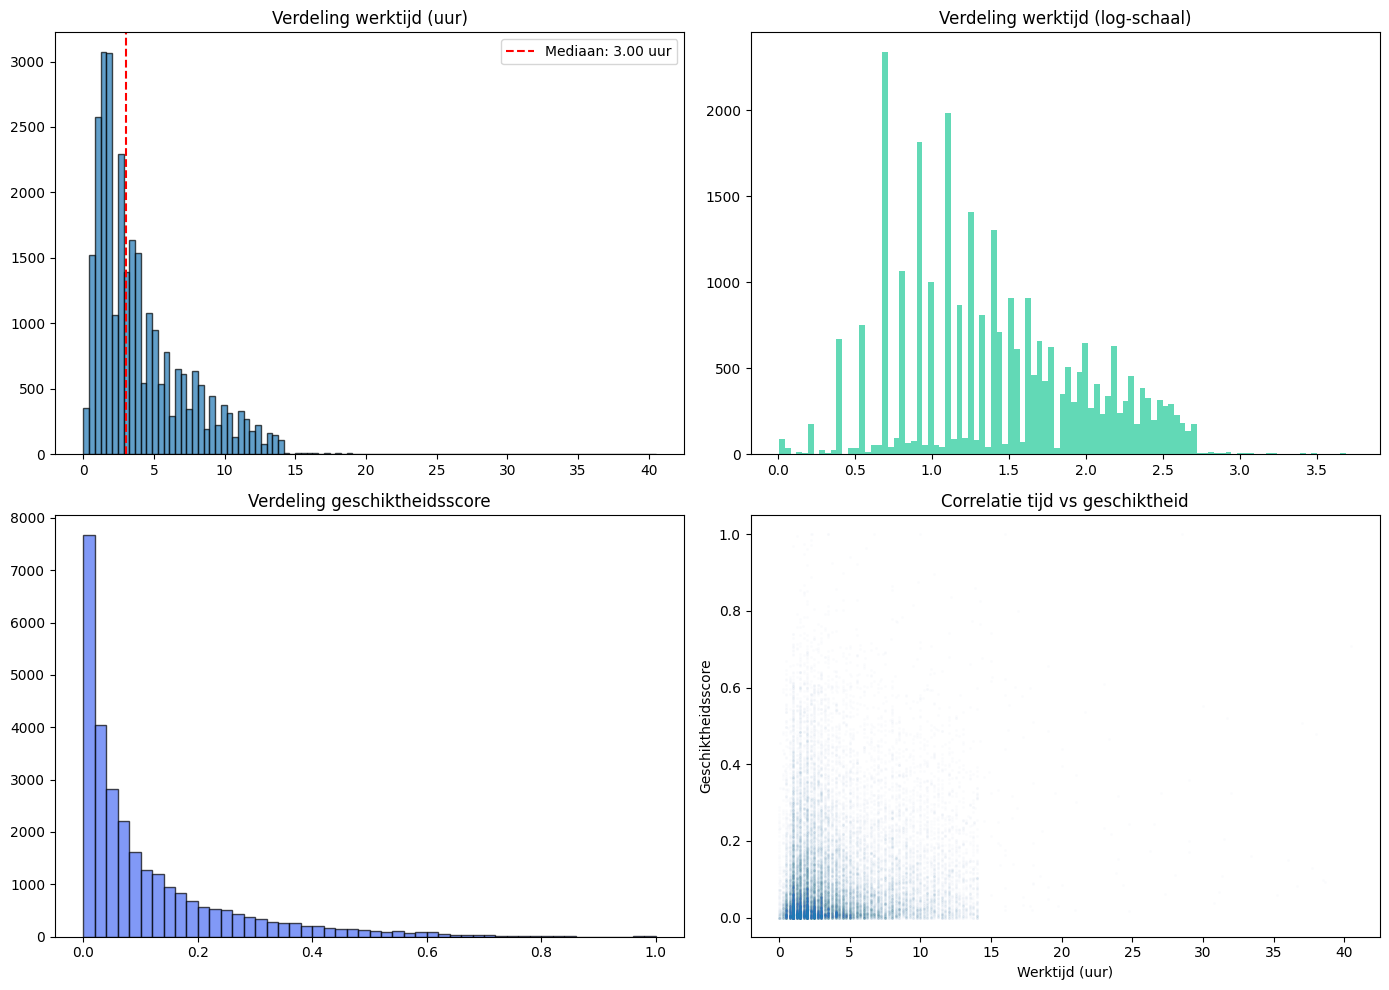

Correlatie tijd-geschiktheid: 0.056


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df[TARGET_TIME], bins=100, edgecolor='black', alpha=0.7)
axes[0,0].axvline(df[TARGET_TIME].median(), color='red', ls='--',
                  label=f'Mediaan: {df[TARGET_TIME].median():.2f} uur')
axes[0,0].set_title('Verdeling werktijd (uur)')
axes[0,0].legend()

axes[0,1].hist(np.log1p(df[TARGET_TIME].clip(lower=0)), bins=100, alpha=0.7, color='#20c997')
axes[0,1].set_title('Verdeling werktijd (log-schaal)')

axes[1,0].hist(df[TARGET_RANK], bins=50, edgecolor='black', alpha=0.7, color='#4c6ef5')
axes[1,0].set_title('Verdeling geschiktheidsscore')

axes[1,1].scatter(df[TARGET_TIME], df[TARGET_RANK], alpha=0.01, s=2)
axes[1,1].set_xlabel('Werktijd (uur)')
axes[1,1].set_ylabel('Geschiktheidsscore')
axes[1,1].set_title('Correlatie tijd vs geschiktheid')

plt.tight_layout()
plt.show()

corr = df[[TARGET_TIME, TARGET_RANK]].corr().iloc[0, 1]
print(f"Correlatie tijd-geschiktheid: {corr:.3f}")

## Stap 7: LGBMRegressor — Tijdsvoorspelling

Optuna zoekt de beste hyperparameters. Objectief: minimaliseer val MAE.

In [34]:
# Probeer beste regressor params op te halen uit MLflow,
# anders draai Optuna tuning.
from mlflow.tracking import MlflowClient
optuna.logging.set_verbosity(optuna.logging.WARNING)

client = MlflowClient()
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

reg_runs = []
if experiment:
    reg_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'reg_trial_%'",
        order_by=['metrics.val_mae ASC'],
        max_results=1,
    )

if reg_runs:
    # Params uit MLflow laden
    best_run = reg_runs[0]
    p = best_run.data.params
    best_reg_params = {
        'objective': p['objective'],
        'metric': p['metric'],
        'verbosity': int(p['verbosity']),
        'n_jobs': int(p['n_jobs']),
        'n_estimators': int(p['n_estimators']),
        'learning_rate': float(p['learning_rate']),
        'max_depth': int(p['max_depth']),
        'num_leaves': int(p['num_leaves']),
        'min_child_samples': int(p['min_child_samples']),
        'subsample': float(p['subsample']),
        'colsample_bytree': float(p['colsample_bytree']),
        'reg_alpha': float(p['reg_alpha']),
        'reg_lambda': float(p['reg_lambda']),
    }
    print(f"Beste regressor trial uit MLflow: {best_run.info.run_name}")
    print(f"Val MAE: {best_run.data.metrics['val_mae']:.4f}")
    print(f"Params: {best_reg_params}")

else:
    # Geen eerdere runs gevonden — Optuna draaien
    print("Geen regressor trials in MLflow, start Optuna tuning...")

    def objective_regressor(trial):
        params = {
            'objective': 'huber',
            'metric': 'mae',
            'verbosity': -1,
            'n_jobs': -1,
            'n_estimators': trial.suggest_int('n_estimators', 200, 2000, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'num_leaves': trial.suggest_int('num_leaves', 16, 256),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
        }

        with mlflow.start_run(run_name=f'reg_trial_{trial.number}', nested=True):
            mlflow.log_params(params)

            model = lgb.LGBMRegressor(**params)
            model.fit(
                X_train, y_time_train,
                eval_set=[(X_val, y_time_val)],
                categorical_feature=CATEGORICAL,
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            preds = model.predict(X_val)
            mae = mean_absolute_error(y_time_val, preds)
            rmse = np.sqrt(mean_squared_error(y_time_val, preds))

            mlflow.log_metrics({
                'val_mae': mae,
                'val_rmse': rmse,
                'best_iteration': model.best_iteration_,
            })

        return mae

    with mlflow.start_run(run_name='optuna_regressor'):
        study_reg = optuna.create_study(direction='minimize', study_name='lgbm_regressor')
        study_reg.optimize(objective_regressor, n_trials=50, show_progress_bar=True)

    best_reg_params = study_reg.best_params
    best_reg_params.update({'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1})

    print(f"\nBeste MAE: {study_reg.best_value:.4f} uur ({study_reg.best_value*60:.1f} min)")
    print(f"Params: {best_reg_params}")

Beste regressor trial uit MLflow: reg_trial_44
Val MAE: 1.2523
Params: {'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1, 'n_estimators': 1700, 'learning_rate': 0.10881321686813049, 'max_depth': 11, 'num_leaves': 178, 'min_child_samples': 19, 'subsample': 0.5341274475726369, 'colsample_bytree': 0.9058537635444641, 'reg_alpha': 1.392965165429018, 'reg_lambda': 0.0004115435660787084}


In [35]:
# Train final regressor met beste params
try:
    best_reg_params = study_reg.best_params
except NameError:
    pass  # best_reg_params is al geladen uit MLflow
best_reg_params.update({'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'n_jobs': -1})

reg_model = lgb.LGBMRegressor(**best_reg_params)
reg_model.fit(
    X_train, y_time_train,
    eval_set=[(X_val, y_time_val)],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print(f"Beste iteratie: {reg_model.best_iteration_}")

[100]	valid_0's l1: 1.41067
[200]	valid_0's l1: 1.3575
[300]	valid_0's l1: 1.32515
[400]	valid_0's l1: 1.29913
[500]	valid_0's l1: 1.28397
[600]	valid_0's l1: 1.27385
[700]	valid_0's l1: 1.26509
[800]	valid_0's l1: 1.25969
[900]	valid_0's l1: 1.25518
[1000]	valid_0's l1: 1.25294
[1100]	valid_0's l1: 1.25252
Beste iteratie: 1070


## Stap 8: LGBMRanker — Geschiktheidsranking

LambdaRank optimaliseert direct op NDCG. De `group` parameter vertelt LightGBM
welke rijen bij dezelfde query (= dezelfde taak) horen, zodat hij leert ranken
binnen een groep medewerkers.

We groeperen op `(con, BEWERKING_ID)` — dezelfde groepen als bij de suitability_score berekening.

In [36]:
# Groepering voor LambdaRank
# Elke groep = rijen met dezelfde (con, BEWERKING_ID) combinatie
GROUP_COLS = ['con', 'BEWERKING_ID']

df['_group_key'] = df[GROUP_COLS].astype(str).agg('__'.join, axis=1)

# LGBMRanker verwacht integer relevance labels.
# Zet suitability_score (0.0 - 1.0) om naar 0-4 relevance levels.
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df['_rank_label'] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

print("Relevance label verdeling:")
print(df['_rank_label'].value_counts().sort_index())

# Sorteer op groep zodat de group sizes kloppen
df_sorted = df.sort_values('_group_key').reset_index(drop=True)

# Split op groepniveau
groups = df_sorted.groupby('_group_key')
group_keys = list(groups.groups.keys())

train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)
train_keys_set = set(train_keys)
val_keys_set = set(val_keys)

train_mask = df_sorted['_group_key'].isin(train_keys_set)
val_mask = df_sorted['_group_key'].isin(val_keys_set)

X_rank_train = df_sorted.loc[train_mask, FEATURES]
X_rank_val   = df_sorted.loc[val_mask, FEATURES]
y_rank_train_sorted = df_sorted.loc[train_mask, '_rank_label'].values
y_rank_val_sorted   = df_sorted.loc[val_mask, '_rank_label'].values

# Bewaar ook de originele float scores voor evaluatie
y_rank_train_float = df_sorted.loc[train_mask, TARGET_RANK].values
y_rank_val_float   = df_sorted.loc[val_mask, TARGET_RANK].values

# Group sizes
train_groups = df_sorted.loc[train_mask].groupby('_group_key').size().values
val_groups   = df_sorted.loc[val_mask].groupby('_group_key').size().values

print(f"\nRank train: {len(X_rank_train):,} rijen in {len(train_groups):,} groepen")
print(f"Rank val:   {len(X_rank_val):,} rijen in {len(val_groups):,} groepen")
print(f"Gemiddelde groepsgrootte: {train_groups.mean():.1f}")

Relevance label verdeling:
_rank_label
0    23299
1     3789
2     1257
3      303
4       45
Name: count, dtype: int64

Rank train: 20,918 rijen in 224 groepen
Rank val:   7,775 rijen in 56 groepen
Gemiddelde groepsgrootte: 93.4


In [37]:
# Probeer beste ranker params op te halen uit MLflow,
# anders draai Optuna tuning.
rank_runs = []
if experiment:
    rank_runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'rank_trial_%'",
        order_by=['metrics.val_ndcg_at_3 DESC'],
        max_results=1,
    )

if rank_runs:
    best_run = rank_runs[0]
    p = best_run.data.params
    best_rank_params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [3, 5],
        'verbosity': -1,
        'n_jobs': -1,
        'n_estimators': int(p['n_estimators']),
        'learning_rate': float(p['learning_rate']),
        'max_depth': int(p['max_depth']),
        'num_leaves': int(p['num_leaves']),
        'min_child_samples': int(p['min_child_samples']),
        'subsample': float(p['subsample']),
        'colsample_bytree': float(p['colsample_bytree']),
        'reg_alpha': float(p['reg_alpha']),
        'reg_lambda': float(p['reg_lambda']),
    }
    print(f"Beste ranker trial uit MLflow: {best_run.info.run_name}")
    print(f"Val NDCG@3: {best_run.data.metrics['val_ndcg_at_3']:.4f}")
    print(f"Params: {best_rank_params}")

else:
    print("Geen ranker trials in MLflow, start Optuna tuning...")

    def objective_ranker(trial):
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'ndcg_eval_at': [3, 5],
            'verbosity': -1,
            'n_jobs': -1,
            'n_estimators': trial.suggest_int('n_estimators', 200, 2000, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'num_leaves': trial.suggest_int('num_leaves', 16, 256),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
        }

        with mlflow.start_run(run_name=f'rank_trial_{trial.number}', nested=True):
            mlflow.log_params({k: v for k, v in params.items() if k != 'ndcg_eval_at'})

            model = lgb.LGBMRanker(**params)
            model.fit(
                X_rank_train, y_rank_train_sorted,
                group=train_groups,
                eval_set=[(X_rank_val, y_rank_val_sorted)],
                eval_group=[val_groups],
                categorical_feature=CATEGORICAL,
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            preds = model.predict(X_rank_val)

            ndcg_scores = []
            offset = 0
            for size in val_groups:
                if size < 2:
                    offset += size
                    continue
                g_true = y_rank_val_float[offset:offset+size]
                g_pred = preds[offset:offset+size]
                ndcg_scores.append(ndcg_score([g_true], [g_pred], k=3))
                offset += size

            mean_ndcg = np.mean(ndcg_scores)
            mlflow.log_metrics({
                'val_ndcg_at_3': mean_ndcg,
                'best_iteration': model.best_iteration_,
            })

        return mean_ndcg

    with mlflow.start_run(run_name='optuna_ranker'):
        study_rank = optuna.create_study(direction='maximize', study_name='lgbm_ranker')
        study_rank.optimize(objective_ranker, n_trials=50, show_progress_bar=True)

    best_rank_params = study_rank.best_params
    best_rank_params.update({
        'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [3, 5],
        'verbosity': -1, 'n_jobs': -1,
    })

    print(f"\nBeste NDCG@3: {study_rank.best_value:.4f}")
    print(f"Params: {best_rank_params}")

Beste ranker trial uit MLflow: rank_trial_30
Val NDCG@3: 0.9403
Params: {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [3, 5], 'verbosity': -1, 'n_jobs': -1, 'n_estimators': 400, 'learning_rate': 0.09813746243348234, 'max_depth': 6, 'num_leaves': 21, 'min_child_samples': 47, 'subsample': 0.5327064294374042, 'colsample_bytree': 0.6819724565321659, 'reg_alpha': 0.00037956719257328006, 'reg_lambda': 0.005748434533518102}


In [38]:
# Train final ranker
try:
    best_rank_params = study_rank.best_params
except NameError:
    pass  # best_rank_params is al geladen uit MLflow
best_rank_params.update({
    'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [3, 5],
    'verbosity': -1, 'n_jobs': -1,
})

rank_model = lgb.LGBMRanker(**best_rank_params)
rank_model.fit(
    X_rank_train, y_rank_train_sorted,
    group=train_groups,
    eval_set=[(X_rank_val, y_rank_val_sorted)],
    eval_group=[val_groups],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print(f"Beste iteratie: {rank_model.best_iteration_}")

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[100]	valid_0's ndcg@3: 0.932658	valid_0's ndcg@5: 0.943438
Beste iteratie: 143


## Stap 9: Evaluatie — Tijdsvoorspelling

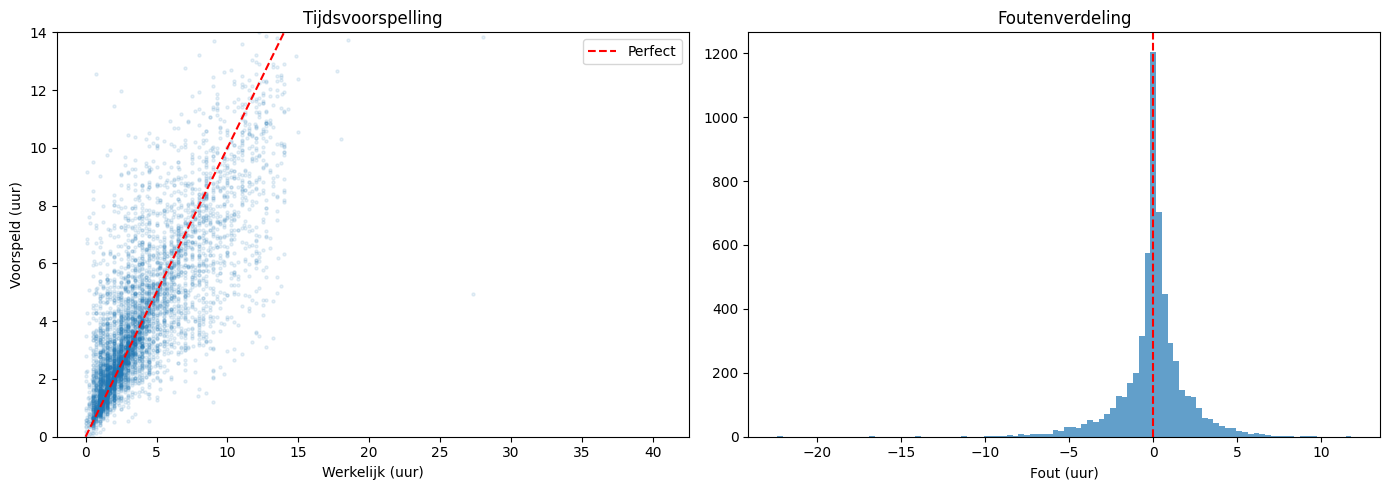

MAE:  1.2523 uur (75.1 min)
RMSE: 1.9806 uur (118.8 min)
R2:   0.6378
KPI:  MAE > 30 min


In [39]:
y_pred_time = reg_model.predict(X_val)

mae = mean_absolute_error(y_time_val, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_time_val, y_pred_time))
r2 = r2_score(y_time_val, y_pred_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_time_val, y_pred_time, alpha=0.1, s=5)
axes[0].plot([0, y_time_val.max()], [0, y_time_val.max()], 'r--', label='Perfect')
axes[0].set_xlabel('Werkelijk (uur)')
axes[0].set_ylabel('Voorspeld (uur)')
axes[0].set_ylim(0, 14)
axes[0].set_title('Tijdsvoorspelling')
axes[0].legend()

errors = y_pred_time - y_time_val
axes[1].hist(errors, bins=100, alpha=0.7)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Foutenverdeling')
axes[1].set_xlabel('Fout (uur)')

plt.tight_layout()
plt.show()

print(f"MAE:  {mae:.4f} uur ({mae*60:.1f} min)")
print(f"RMSE: {rmse:.4f} uur ({rmse*60:.1f} min)")
print(f"R2:   {r2:.4f}")
print(f"KPI:  MAE {'<= 30 min' if mae*60 <= 30 else '> 30 min'}")

## Stap 10: Evaluatie — Ranking

NDCG@3: 0.9403
NDCG@5: 0.9480


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


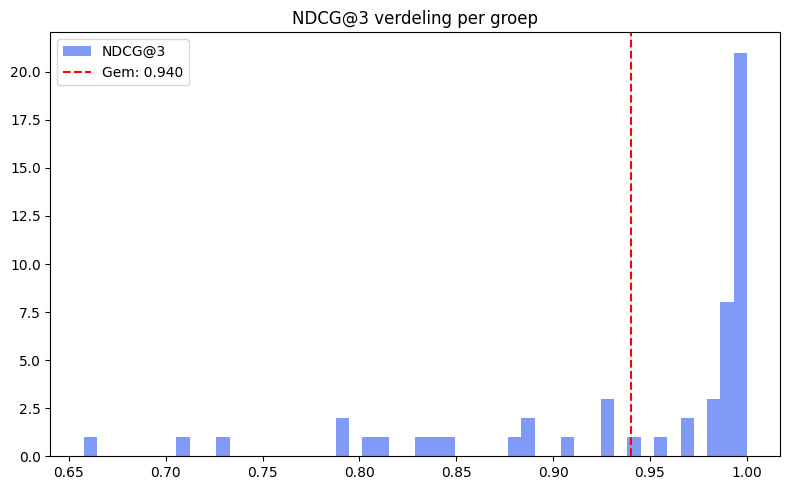

In [40]:
y_pred_rank = rank_model.predict(X_rank_val)

# NDCG per groep (op originele float scores)
ndcg3_scores, ndcg5_scores = [], []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_val_float[offset:offset+size]
    g_pred = y_pred_rank[offset:offset+size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

print(f"NDCG@3: {np.mean(ndcg3_scores):.4f}")
print(f"NDCG@5: {np.mean(ndcg5_scores):.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ndcg3_scores, bins=50, alpha=0.7, label='NDCG@3', color='#4c6ef5')
ax.axvline(np.mean(ndcg3_scores), color='red', ls='--', label=f'Gem: {np.mean(ndcg3_scores):.3f}')
ax.set_title('NDCG@3 verdeling per groep')
ax.legend()
plt.tight_layout()
plt.show()

## Stap 11: Top-3 Hit Rate

In [41]:
def bereken_top_k_hit_rate(reg_model, rank_model, X_val, val_idx, df, k=3, n_samples=500):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row['con']
        werkelijke_med = row['URENVERANTW_MEDID']

        db_mask = df['con'] == db_id
        alle_medewerkers = df.loc[db_mask, 'URENVERANTW_MEDID'].unique()
        if len(alle_medewerkers) < 2:
            continue

        # Maak batch: dezelfde taak-features, maar wissel medewerker
        batch = pd.DataFrame([row[FEATURES]] * len(alle_medewerkers))
        batch.columns = FEATURES
        batch['URENVERANTW_MEDID'] = alle_medewerkers
        for col in CATEGORICAL:
            batch[col] = batch[col].astype('category')

        scores = rank_model.predict(batch)
        top_k_meds = alle_medewerkers[np.argsort(scores)[-k:]]

        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0, hits, total

print("Berekenen top-3 hit rate...")
hit_rate, hits, total = bereken_top_k_hit_rate(reg_model, rank_model, X_val, val_idx, df)
print(f"Top-3 hit rate: {hits}/{total} = {hit_rate:.1%}")
print(f"KPI: {'>= 80%' if hit_rate >= 0.80 else '< 80%'}")

Berekenen top-3 hit rate...


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument


Top-3 hit rate: 101/497 = 20.3%
KPI: < 80%


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument


## Stap 12: Feature Importance

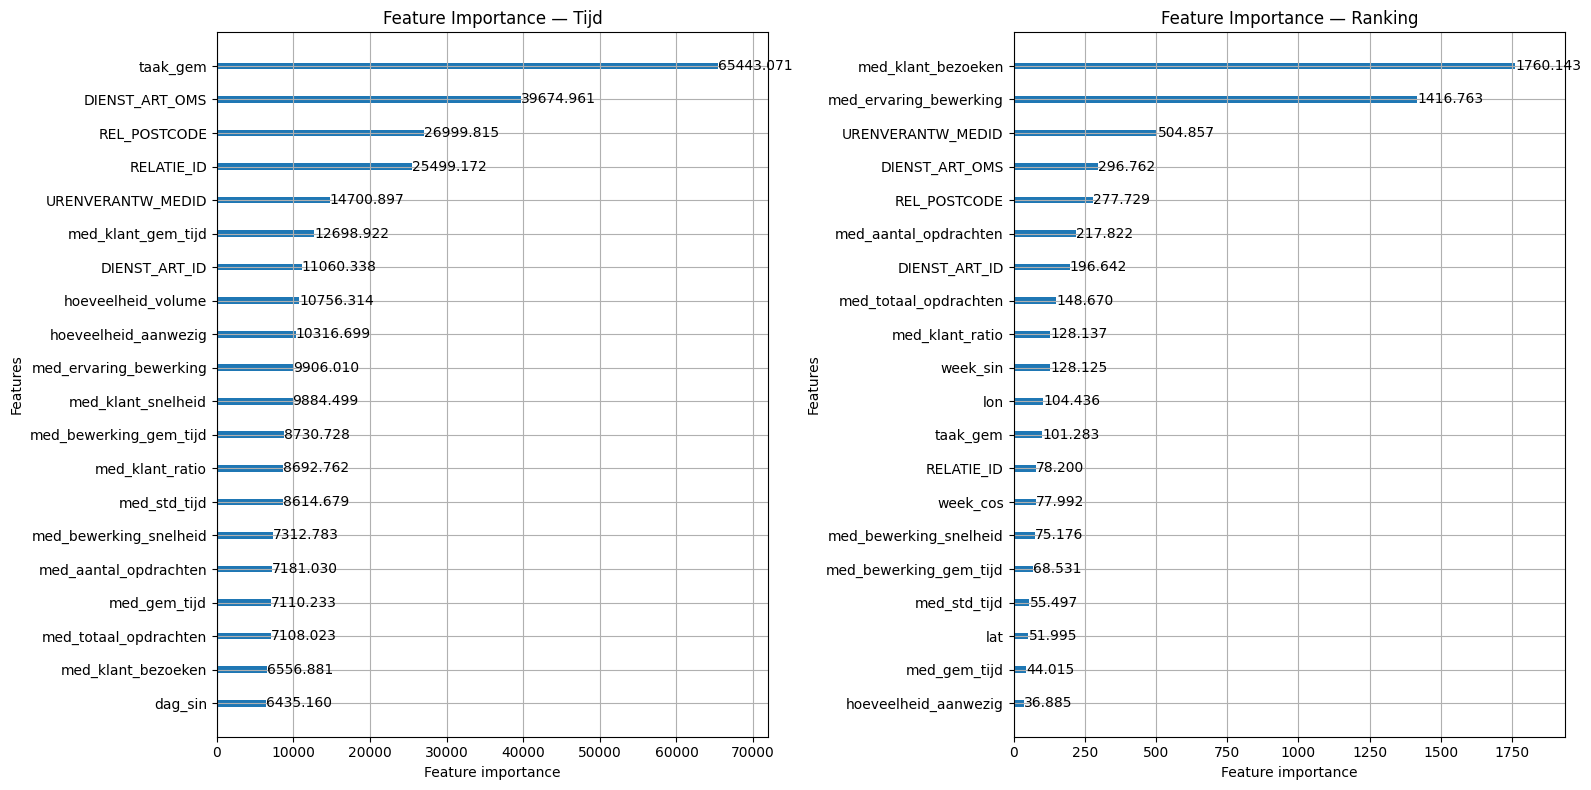

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Regressor importance
lgb.plot_importance(reg_model, ax=axes[0], max_num_features=20,
                    importance_type='gain', title='Feature Importance — Tijd')

# Ranker importance
lgb.plot_importance(rank_model, ax=axes[1], max_num_features=20,
                    importance_type='gain', title='Feature Importance — Ranking')

plt.tight_layout()
plt.show()

## Stap 13: Fine-tuning per database

LightGBM fine-tuning werkt via `init_model`: laad het basismodel en train verder
met een lagere learning rate en minder bomen.

In [43]:
DB_KOLOM = 'con'
finetuned_reg = {}
finetuned_rank = {}

for db_id in df[DB_KOLOM].unique():
    db_mask = df[DB_KOLOM] == db_id
    db_indices = df.index[db_mask].values

    if len(db_indices) < 500:
        print(f"{db_id}: {len(db_indices)} rijen — te weinig, gebruikt basismodel")
        continue

    tr, va = train_test_split(db_indices, test_size=0.2, random_state=42)
    X_ft_train = df.loc[tr, FEATURES]
    X_ft_val   = df.loc[va, FEATURES]

    # --- Regressor fine-tune ---
    ft_reg = lgb.LGBMRegressor(
        objective='huber', metric='mae', verbosity=-1, n_jobs=-1,
        n_estimators=100, learning_rate=0.01,
    )
    ft_reg.fit(
        X_ft_train, df.loc[tr, TARGET_TIME].values,
        eval_set=[(X_ft_val, df.loc[va, TARGET_TIME].values)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(20, verbose=False)],
        init_model=reg_model,
    )
    ft_mae = mean_absolute_error(df.loc[va, TARGET_TIME], ft_reg.predict(X_ft_val))
    finetuned_reg[db_id] = ft_reg

    # --- Ranker fine-tune ---
    db_sorted = df.loc[db_mask].sort_values('_group_key')
    unique_groups = db_sorted['_group_key'].unique()

    if len(unique_groups) < 5:
        print(f"{db_id}: {len(db_indices)} rijen, {len(unique_groups)} groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: {ft_mae:.4f})")
        continue

    db_tr_keys, db_va_keys = train_test_split(
        unique_groups, test_size=0.2, random_state=42
    )
    db_tr_mask = db_sorted['_group_key'].isin(set(db_tr_keys))
    db_va_mask = db_sorted['_group_key'].isin(set(db_va_keys))

    ft_rank = lgb.LGBMRanker(
        objective='lambdarank', metric='ndcg', ndcg_eval_at=[3, 5],
        verbosity=-1, n_jobs=-1, n_estimators=100, learning_rate=0.01,
    )
    ft_rank.fit(
        db_sorted.loc[db_tr_mask, FEATURES],
        db_sorted.loc[db_tr_mask, '_rank_label'].values,
        group=db_sorted.loc[db_tr_mask].groupby('_group_key').size().values,
        eval_set=[(db_sorted.loc[db_va_mask, FEATURES],
                   db_sorted.loc[db_va_mask, '_rank_label'].values)],
        eval_group=[db_sorted.loc[db_va_mask].groupby('_group_key').size().values],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(20, verbose=False)],
        init_model=rank_model,
    )

    finetuned_rank[db_id] = ft_rank
    print(f"{db_id}: {len(db_indices)} rijen — fine-tuned, val MAE: {ft_mae:.4f} uur")

15_poel: 119 rijen — te weinig, gebruikt basismodel
18_westra: 5 rijen — te weinig, gebruikt basismodel
19_westra: 14 rijen — te weinig, gebruikt basismodel
20_westra: 164 rijen — te weinig, gebruikt basismodel
21_diepen: 521 rijen, 3 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.3303)


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


21_jennissen: 3790 rijen — fine-tuned, val MAE: 0.5032 uur
21_westra: 196 rijen — te weinig, gebruikt basismodel
21_melse: 30 rijen — te weinig, gebruikt basismodel
22_westra: 209 rijen — te weinig, gebruikt basismodel


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


22_jennissen: 3807 rijen — fine-tuned, val MAE: 0.5301 uur
22_diepen: 590 rijen, 2 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.3698)
24_kuijpers: 147 rijen — te weinig, gebruikt basismodel
25_kuijpers: 118 rijen — te weinig, gebruikt basismodel
22_melse: 33 rijen — te weinig, gebruikt basismodel
23_melse: 42 rijen — te weinig, gebruikt basismodel
22_poel: 5 rijen — te weinig, gebruikt basismodel
23_diepen: 551 rijen, 3 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.2482)


...

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


25_jennissen: 3804 rijen — fine-tuned, val MAE: 0.4163 uur


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


25_diepen: 546 rijen — fine-tuned, val MAE: 0.2310 uur
25_derks: 67 rijen — te weinig, gebruikt basismodel
25_melse: 130 rijen — te weinig, gebruikt basismodel
a46b0d64-2b99-41a4-8137-0e589a9c246f: 19 rijen — te weinig, gebruikt basismodel
5e8016f5-e1fc-4e15-85c2-a1c8516aee7b: 8 rijen — te weinig, gebruikt basismodel
39bf3eb6-b8c2-4832-8f92-d89e9e58ac38: 50 rijen — te weinig, gebruikt basismodel
f512c336-8c9f-4260-a644-56e14bb2f203: 11 rijen — te weinig, gebruikt basismodel
89c40dca-4cac-4b9d-9636-951596393ede: 101 rijen — te weinig, gebruikt basismodel
47e405ef-a15f-40bc-be06-a33199799b12: 24 rijen — te weinig, gebruikt basismodel
22c76114-3ea7-443d-abcd-02c890a9711e: 2 rijen — te weinig, gebruikt basismodel
40468dd2-328f-4542-b69e-3882aecc8099: 17 rijen — te weinig, gebruikt basismodel
9c822f1c-e7d1-4dd7-b814-148ffce6cace: 1 rijen — te weinig, gebruikt basismodel
78eca0d2-4a24-4693-9c34-ddffc9729926: 133 rijen — te weinig, gebruikt basismodel
15ed8277-73c5-4aac-aefb-3978e1c7ecc7: 91 

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


## Stap 14: Voorspellen — "Wie moet ik inplannen?"

In [44]:
def voorspel_per_medewerker(reg_m, rank_m, taak_row, medewerkers, features):
    batch = pd.DataFrame([taak_row[features]] * len(medewerkers))
    batch.columns = features
    batch['URENVERANTW_MEDID'] = medewerkers
    for col in CATEGORICAL:
        batch[col] = batch[col].astype('category')

    result = pd.DataFrame({
        'medewerker': medewerkers,
        'uren': np.clip(reg_m.predict(batch), 0, None).round(2),
        'geschiktheid': rank_m.predict(batch).round(3),
    })
    return result.sort_values('geschiktheid', ascending=False).reset_index(drop=True)

# Voorbeeld
val_row_idx = np.random.choice(len(val_idx))
orig_idx = val_idx[val_row_idx]
row = df.iloc[orig_idx]
db_id = row['con']

alle_meds = df.loc[df['con'] == db_id, 'URENVERANTW_MEDID'].unique()
r_model = finetuned_reg.get(db_id, reg_model)
k_model = finetuned_rank.get(db_id, rank_model)

result = voorspel_per_medewerker(r_model, k_model, row, alle_meds, FEATURES)

print(f"Opdracht: index {orig_idx} (database: {db_id})")
print(f"Werkelijke medewerker: {row['URENVERANTW_MEDID']}")
print(f"Werkelijke tijd: {row[TARGET_TIME]:.2f} uur")
print(f"\nTop 10 medewerkers:")
print(result.head(10).to_string(index=False))

Opdracht: index 25571 (database: 25_jennissen)
Werkelijke medewerker: 163
Werkelijke tijd: 0.25 uur

Top 10 medewerkers:
medewerker  uren  geschiktheid
       150  0.40        -3.150
       120  0.66        -3.188
       154  0.98        -3.211
       104  0.83        -3.286
       119  1.00        -3.551
       161  0.72        -3.806
       165  0.62        -4.045
       179  0.80        -4.048
       158  0.76        -4.079
       125  1.06        -4.101


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


## Stap 15: Modellen opslaan

In [45]:
os.makedirs('models', exist_ok=True)

# Basismodellen
reg_model.booster_.save_model('models/lgbm_regressor.txt')
rank_model.booster_.save_model('models/lgbm_ranker.txt')
print("Opgeslagen: models/lgbm_regressor.txt, models/lgbm_ranker.txt")

for db_id, ft_reg in finetuned_reg.items():
    ft_reg.booster_.save_model(f'models/lgbm_regressor_{db_id}.txt')
    if db_id in finetuned_rank:
        finetuned_rank[db_id].booster_.save_model(f'models/lgbm_ranker_{db_id}.txt')
        print(f"Opgeslagen: models/lgbm_regressor_{db_id}.txt + lgbm_ranker_{db_id}.txt")
    else:
        print(f"Opgeslagen: models/lgbm_regressor_{db_id}.txt (geen ranker, gebruikt basismodel)")

# Metadata voor C# API
metadata = {
    'categorical_features': CATEGORICAL,
    'numerical_features': NUMERICAL,
    'all_features': FEATURES,
    'target_time': TARGET_TIME,
    'target_rank': TARGET_RANK,
    'best_reg_params': best_reg_params,
    'best_rank_params': {k: v for k, v in best_rank_params.items() if k != 'ndcg_eval_at'},
    'finetuned_databases': list(finetuned_reg.keys()),
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("Opgeslagen: models/metadata.json")

Opgeslagen: models/lgbm_regressor.txt, models/lgbm_ranker.txt
Opgeslagen: models/lgbm_regressor_21_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_21_jennissen.txt + lgbm_ranker_21_jennissen.txt
Opgeslagen: models/lgbm_regressor_22_jennissen.txt + lgbm_ranker_22_jennissen.txt
Opgeslagen: models/lgbm_regressor_22_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_23_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_23_jennissen.txt + lgbm_ranker_23_jennissen.txt
Opgeslagen: models/lgbm_regressor_23_hulter.txt + lgbm_ranker_23_hulter.txt
Opgeslagen: models/lgbm_regressor_24_jennissen.txt + lgbm_ranker_24_jennissen.txt
Opgeslagen: models/lgbm_regressor_24_hulter.txt + lgbm_ranker_24_hulter.txt
Opgeslagen: models/lgbm_regressor_24_diepen.txt (geen ranker, gebruikt basismodel)
Opgeslagen: models/lgbm_regressor_25_hulter.txt + lgbm_ranker_25_hulter.txt
Opgeslagen: models/lgbm_regressor_25_jennissen.txt

## Stap 16: ONNX Export

Twee aparte ONNX bestanden: één voor regressie, één voor ranking.
Officieel ondersteund via `onnxmltools.convert_lightgbm()` sinds v1.16.0.

In [46]:
import onnxmltools
from onnxmltools.convert.lightgbm.convert import convert as convert_lgbm
from skl2onnx.common.data_types import FloatTensorType, StringTensorType
import onnxruntime as ort

os.makedirs('models_onnx', exist_ok=True)

n_features = len(FEATURES)

# --- Regressor ONNX ---
initial_types = [('features', FloatTensorType([None, n_features]))]
onnx_reg = onnxmltools.convert_lightgbm(
    reg_model, initial_types=initial_types, target_opset=15
)
onnxmltools.utils.save_model(onnx_reg, 'models_onnx/lgbm_regressor.onnx')
print("Regressor ONNX: models_onnx/lgbm_regressor.onnx")

# --- Ranker ONNX ---
onnx_rank = onnxmltools.convert_lightgbm(
    rank_model, initial_types=initial_types, target_opset=15
)
onnxmltools.utils.save_model(onnx_rank, 'models_onnx/lgbm_ranker.onnx')
print("Ranker ONNX: models_onnx/lgbm_ranker.onnx")

Regressor ONNX: models_onnx/lgbm_regressor.onnx
Ranker ONNX: models_onnx/lgbm_ranker.onnx


In [47]:
# Verificatie: LightGBM vs ONNX output
test_df = X_val.head(5).copy()

# Categorische kolommen omzetten naar hun integer codes
for col in CATEGORICAL:
    test_df[col] = test_df[col].cat.codes.astype(np.float32)

test_data = test_df.values.astype(np.float32)

# Regressor check
sess_reg = ort.InferenceSession('models_onnx/lgbm_regressor.onnx')
onnx_time_pred = sess_reg.run(None, {'features': test_data})[0].flatten()
lgbm_time_pred = reg_model.predict(X_val.head(5))

print("REGRESSOR — LightGBM vs ONNX (5 samples):")
for i in range(5):
    print(f"  {i}: LightGBM={lgbm_time_pred[i]:.4f}  ONNX={onnx_time_pred[i]:.4f}")
print(f"Max verschil: {np.max(np.abs(lgbm_time_pred - onnx_time_pred)):.8f}")

REGRESSOR — LightGBM vs ONNX (5 samples):
  0: LightGBM=0.2811  ONNX=0.2757
  1: LightGBM=3.3062  ONNX=3.3213
  2: LightGBM=1.5240  ONNX=1.4627
  3: LightGBM=1.5065  ONNX=1.5065
  4: LightGBM=6.3982  ONNX=6.3982
Max verschil: 0.06125457


In [48]:
cat_code_mapping = {}
for col in CATEGORICAL:
    cat_code_mapping[col] = dict(zip(
        X_val[col].cat.categories.tolist(),
        range(len(X_val[col].cat.categories))
    ))

with open('models/cat_codes.json', 'w') as f:
    json.dump(cat_code_mapping, f, indent=2)

In [49]:
# Fine-tuned modellen naar ONNX
for db_id in finetuned_reg:
    try:
        onnx_ft_reg = onnxmltools.convert_lightgbm(
            finetuned_reg[db_id], initial_types=initial_types, target_opset=15
        )
        onnxmltools.utils.save_model(onnx_ft_reg, f'models_onnx/lgbm_regressor_{db_id}.onnx')

        onnx_ft_rank = onnxmltools.convert_lightgbm(
            finetuned_rank[db_id], initial_types=initial_types, target_opset=15
        )
        onnxmltools.utils.save_model(onnx_ft_rank, f'models_onnx/lgbm_ranker_{db_id}.onnx')

        print(f"  {db_id} -> ONNX OK")
    except Exception as e:
        print(f"  {db_id} -> FOUT: {e}")


  21_diepen -> FOUT: '21_diepen'
  21_jennissen -> ONNX OK
  22_jennissen -> ONNX OK
  22_diepen -> FOUT: '22_diepen'
  23_diepen -> FOUT: '23_diepen'
  23_jennissen -> ONNX OK
  23_hulter -> ONNX OK
  24_jennissen -> ONNX OK
  24_hulter -> ONNX OK
  24_diepen -> FOUT: '24_diepen'
  25_hulter -> ONNX OK
  25_jennissen -> ONNX OK
  25_diepen -> ONNX OK
  f5ab1b29-de37-4818-bb05-b2fe57ce6768 -> ONNX OK


## Stap 17: MLflow logging

In [50]:
with mlflow.start_run(run_name='lightgbm_final') as run:
    # Params
    mlflow.log_params({f'reg_{k}': v for k, v in best_reg_params.items()})
    mlflow.log_params({f'rank_{k}': v for k, v in best_rank_params.items()
                       if k != 'ndcg_eval_at'})

    # Metrics
    mlflow.log_metrics({
        'time_mae': mae,
        'time_rmse': rmse,
        'time_r2': r2,
        'ndcg_at_3': np.mean(ndcg3_scores),
        'ndcg_at_5': np.mean(ndcg5_scores),
        'top3_hit_rate': hit_rate,
        'dataset_rows': len(df),
    })

    # ONNX modellen loggen
    mlflow.onnx.log_model(onnx_reg, name="lgbm_regressor")
    mlflow.onnx.log_model(onnx_rank, name="lgbm_ranker")

    # Extra artifacts
    for f, artifact_path in [
        ('models/lgbm_regressor.txt', None),
        ('models/lgbm_ranker.txt', None),
        ('models/metadata.json', None),
        ('models_onnx/lgbm_regressor.onnx', 'onnx'),
        ('models_onnx/lgbm_ranker.onnx', 'onnx'),
        ('models/cat_codes.json', 'artifacts'),
    ]:
        if os.path.exists(f):
            mlflow.log_artifact(f, **({'artifact_path': artifact_path} if artifact_path else {}))

    run_id = run.info.run_id

🏃 View run lightgbm_final at: http://127.0.0.1:5001/#/experiments/4/runs/5fb6028889c74c4e871dd36d99a9fa31
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


In [51]:
client = MlflowClient()

def get_best_registry_mae(model_name):
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
        maes = []
        for v in versions:
            metrics = client.get_run(v.run_id).data.metrics
            if 'time_mae' in metrics:
                maes.append(metrics['time_mae'])
        return min(maes) if maes else float('inf')
    except Exception:
        return float('inf')  # Model bestaat nog niet → altijd registreren

best_mae_in_registry = get_best_registry_mae("rister-lgbm-regressor")

if mae < best_mae_in_registry:
    mlflow.register_model(f"runs:/{run_id}/lgbm_regressor", "rister-lgbm-regressor")
    mlflow.register_model(f"runs:/{run_id}/lgbm_ranker",    "rister-lgbm-ranker")
    print(f"Nieuwe beste versie geregistreerd! MAE: {mae:.4f} (was: {best_mae_in_registry:.4f})")
else:
    print(f"Niet geregistreerd — huidige MAE ({mae:.4f}) is niet beter dan registry ({best_mae_in_registry:.4f})")

Niet geregistreerd — huidige MAE (1.2523) is niet beter dan registry (1.2523)


## Stap 18: Samenvatting

| Eigenschap | MMoE (vorig) | LightGBM (dit) |
|---|---|---|
| Architectuur | N expert MLPs + gating | 2x GBDT (regressor + ranker) |
| Categorische features | Entity embeddings + LabelEncoder | Native (`categorical_feature`) |
| Ranking objectief | MSE op suitability_score | LambdaRank (optimaliseert NDCG direct) |
| Fine-tuning | Freeze experts, train towers | `init_model` + lage learning rate |
| ONNX export | PyTorch `torch.onnx.export` | `onnxmltools.convert_lightgbm()` |
| GPU nodig | Ja (MPS/CUDA) | Nee |
| Training tijd | ~30-60 min | ~5-10 min |
| Inference | ~0.1-1ms | ~0.01-0.1ms |

In [52]:
import mlflow
import onnxruntime as rt

mlflow.set_tracking_uri("http://10.0.0.100:5001")

mlflow.artifacts.download_artifacts(
    artifact_uri="models:/rister-lgbm-regressor/1",
    dst_path="/tmp/mlflow_models/regressor"
)

mlflow.artifacts.download_artifacts(
    artifact_uri="models:/rister-lgbm-ranker/1",
    dst_path="/tmp/mlflow_models/ranker"
)


# Inspect beide
for name, path in [
    ("REGRESSOR", "/tmp/mlflow_models/regressor/model.onnx"),
    ("RANKER",    "/tmp/mlflow_models/ranker/model.onnx"),
]:
    sess = rt.InferenceSession(path)
    print(f"\n=== {name} ===")
    print("INPUTS:")
    for i in sess.get_inputs():
        print(f"  name={i.name!r}  shape={i.shape}  type={i.type}")
    print("OUTPUTS:")
    for o in sess.get_outputs():
        print(f"  name={o.name!r}  shape={o.shape}  type={o.type}")


=== REGRESSOR ===
INPUTS:
  name='features'  shape=[None, 36]  type=tensor(float)
OUTPUTS:
  name='variable'  shape=[None, 1]  type=tensor(float)

=== RANKER ===
INPUTS:
  name='features'  shape=[None, 36]  type=tensor(float)
OUTPUTS:
  name='variable'  shape=[None, 1]  type=tensor(float)
